In [18]:
import os
import random
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

DATA_DIR = Path('../data/raw/plantvillage')
print('Path exists:', DATA_DIR.exists())
print('Subfolders found:', len(list(DATA_DIR.iterdir())))

Path exists: True
Subfolders found: 15


In [19]:
import os
print(os.getcwd())  # shows where Jupyter thinks you are right now

C:\Users\DELL\Desktop\kisanai-ml\notebooks


In [20]:
import os
print(os.listdir('../data/raw'))

['PlantVillage']


In [21]:
from pathlib import Path

DATA_DIR = Path('../data/raw')

for plant_folder in sorted(DATA_DIR.iterdir()):
    if plant_folder.is_dir():
        subfolders = [d.name for d in plant_folder.iterdir() if d.is_dir()]
        print(f"{plant_folder.name}/ → {len(subfolders)} classes: {subfolders}")

PlantVillage/ → 15 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [22]:
import os
import random
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

DATA_DIR = Path('../data/raw/PlantVillage')

print('Path exists:', DATA_DIR.exists())

# List only actual disease class folders (skip the nested PlantVillage folder)
classes = sorted([
    d.name for d in DATA_DIR.iterdir()
])

print('Classes found:', len(classes))
print(classes)

Path exists: True
Classes found: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [23]:
class_counts = {}
for cls in classes:
    imgs = list((DATA_DIR / cls).glob('*.jpg'))
    class_counts[cls] = len(imgs)
    print(f"{cls}:{len(imgs)} images")

Pepper__bell___Bacterial_spot:997 images
Pepper__bell___healthy:1477 images
Potato___Early_blight:1000 images
Potato___Late_blight:1000 images
Potato___healthy:152 images
Tomato_Bacterial_spot:2127 images
Tomato_Early_blight:1000 images
Tomato_Late_blight:1908 images
Tomato_Leaf_Mold:952 images
Tomato_Septoria_leaf_spot:1771 images
Tomato_Spider_mites_Two_spotted_spider_mite:1676 images
Tomato__Target_Spot:1404 images
Tomato__Tomato_YellowLeaf__Curl_Virus:3208 images
Tomato__Tomato_mosaic_virus:373 images
Tomato_healthy:1591 images


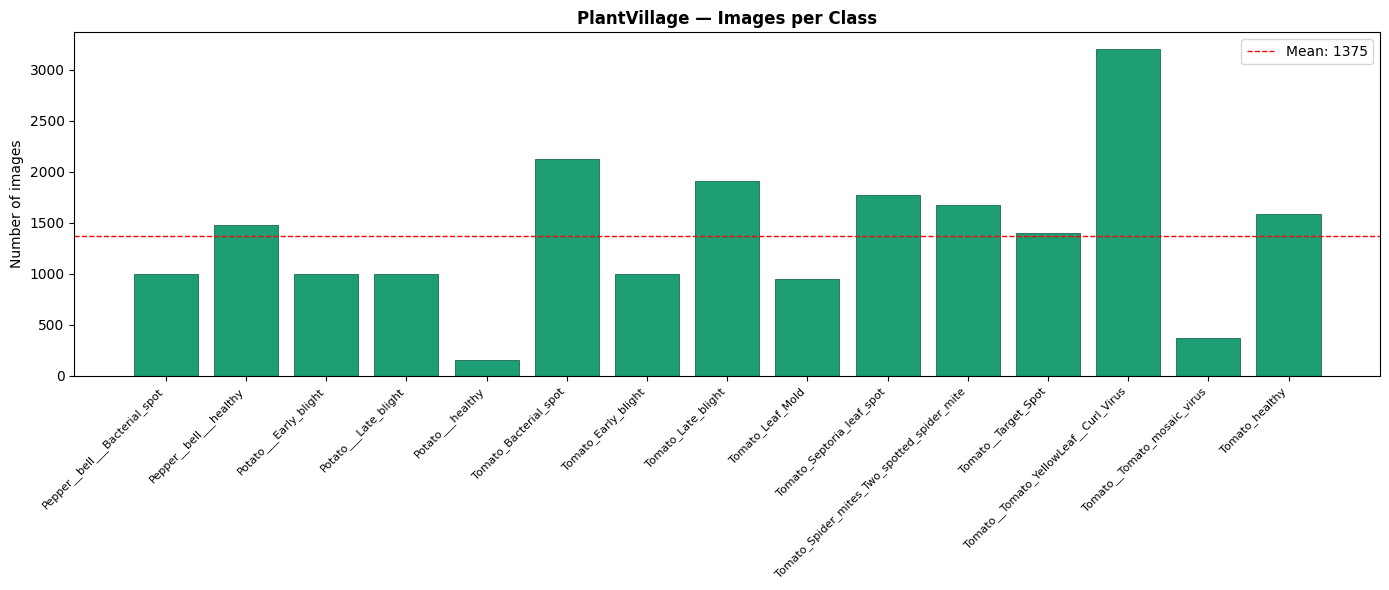

Smallest: Potato___healthy (152 images)
Largest : Tomato__Tomato_YellowLeaf__Curl_Virus (3208 images)
Mean    : 1375 images
Total   : 20636 images


In [30]:
fig, ax = plt.subplots(figsize=(14,6))
names = list(class_counts.keys())
counts = list(class_counts.values())
# print(names, counts)
bars = ax.bar(range(len(names)), counts, color='#1D9E75', edgecolor='#085041', linewidth=0.5)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, fontsize=8, ha='right')
ax.set_ylabel('Number of images')
ax.set_title('PlantVillage — Images per Class', fontweight='bold')
ax.axhline(
    y=sum(counts)/len(counts),
    color='red', linestyle='--', linewidth=1,
    label=f'Mean: {sum(counts)//len(counts)}'
)
ax.legend()
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
min_cls = min(class_counts, key=class_counts.get)
max_cls = max(class_counts, key=class_counts.get)
print(f"Smallest: {min_cls} ({class_counts[min_cls]} images)")
print(f"Largest : {max_cls} ({class_counts[max_cls]} images)")
print(f"Mean    : {sum(counts)//len(counts)} images")
print(f"Total   : {sum(counts)} images")



FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/sample_images.png'

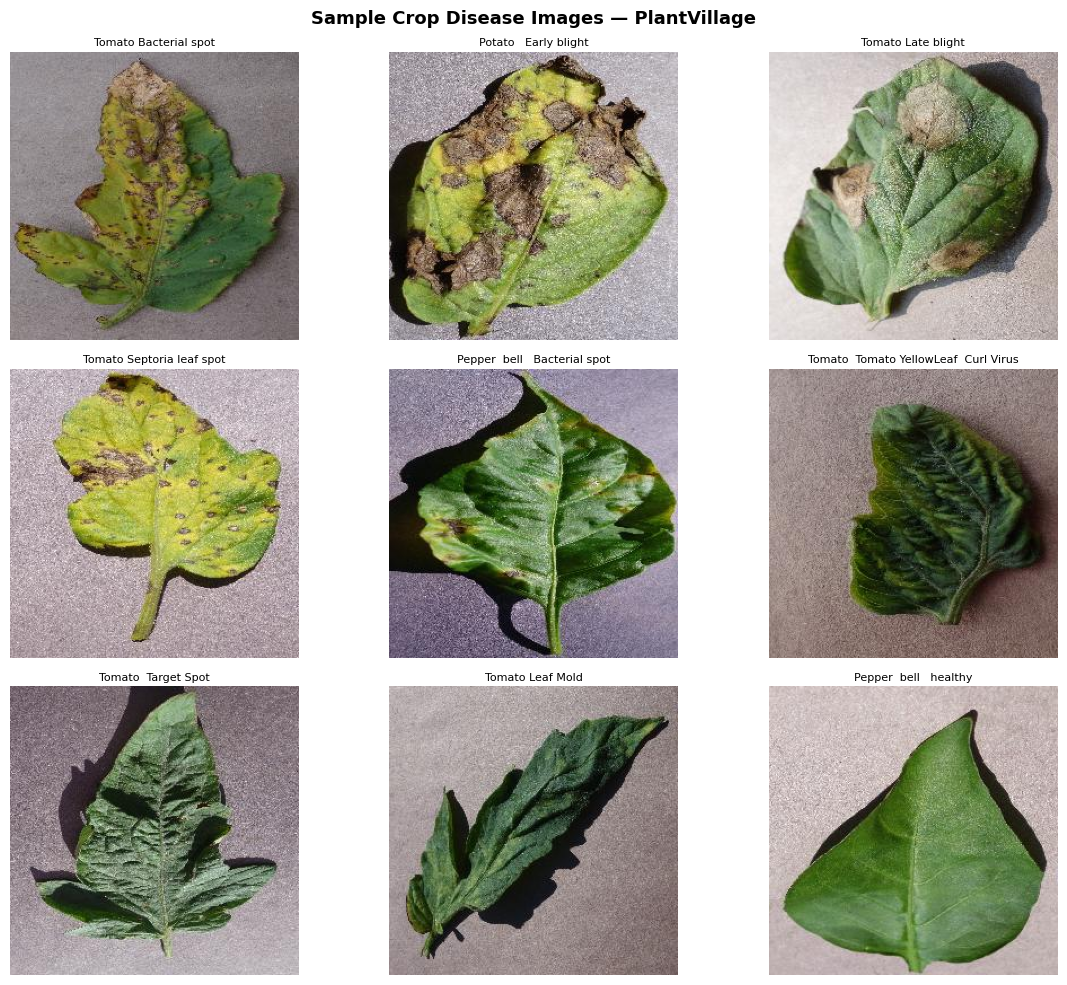

In [25]:
sample_classes = random.sample(classes, 9)
fig, axes = plt.subplots(3, 3, figsize=(12,10))

for ax, cls in zip(axes.flatten(), sample_classes):
    img_files = list((DATA_DIR / cls).glob('*.jpg'))
    img_path  = random.choice(img_files)
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(cls.replace('_', ' '), fontsize=8, pad=4)
    ax.axis('off')

plt.suptitle('Sample Crop Disease Images — PlantVillage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved sample_images.png")

In [26]:
all_images = list(DATA_DIR.rglob('*.jpg'))
sample = random.sample(all_images, min(200, len(all_images)))
sizes = []

for img_path in sample:
    with Image.open(img_path) as img:
        sizes.append(img.size)

widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
print(f"Width  — min: {min(widths)}, max: {max(widths)}, avg: {sum(widths)//len(widths)}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, avg: {sum(heights)//len(heights)}")
print(f"\nTotal images found: {len(all_images)}")

Width  — min: 256, max: 256, avg: 256
Height — min: 256, max: 256, avg: 256

Total images found: 20636


In [27]:
corrupted = []

for img_path in all_images:
    try:
        with Image.open(img_path) as img:
            img.verify()
    except Exception:
        corrupted.append(str(img_path))

print(f"Corrupted images: {len(corrupted)}")
if corrupted:
    for c in corrupted:
        print(c)
else:
    print("All images are clean. Ready for training.")

Corrupted images: 0
All images are clean. Ready for training.


In [28]:
print(f"Corrupted images: {len(corrupted)}")
print("All images are clean. Ready for training.")

Corrupted images: 0
All images are clean. Ready for training.


In [29]:
findings = {
    "total_classes"  : len(classes),
    "total_images"   : sum(class_counts.values()),
    "class_names"    : classes,
    "class_counts"   : class_counts,
    "min_class"      : {"name": min_cls, "count": class_counts[min_cls]},
    "max_class"      : {"name": max_cls, "count": class_counts[max_cls]},
    "mean_per_class" : sum(counts)//len(counts),
    "image_size"     : "256x256 (will resize to 224x224 for EfficientNetB0)",
    "corrupted_count": len(corrupted),
}

with open('notebooks/eda_findings.json', 'w') as f:
    json.dump(findings, f, indent=2)

print("Saved eda_findings.json")
print(f"\n--- Summary ---")
print(f"Classes  : {findings['total_classes']}")
print(f"Images   : {findings['total_images']}")
print(f"Smallest : {findings['min_class']}")
print(f"Largest  : {findings['max_class']}")
print(f"Mean     : {findings['mean_per_class']} images per class")
print(f"Corrupted: {findings['corrupted_count']}")

NameError: name 'min_cls' is not defined